## 📦 Setup & Initialization
**Description:** Imports analytical and visualization libraries and loads the primary metadata. Sets up the environment for static plotting (`seaborn`, `matplotlib`) and interactive visualization (`plotly`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set publication-quality style for seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =====================================================================
# 1. LOAD DATASET
# =====================================================================
# Update this path to match your local directory structure
METADATA_CSV_PATH = r"d:\Resfes\Project\Ser\data\DataFrames\iemocap_metadata.csv"

print("[INFO] Loading IEMOCAP metadata...")
try:
    df = pd.read_csv(METADATA_CSV_PATH)
    # Ensure temporal chronological order
    df = df.sort_values(by=['Session', 'Dialog_ID', 'Turn_Order']).reset_index(drop=True)
    print(f"[SUCCESS] Loaded {len(df)} utterances.")
    display(df.head())
except Exception as e:
    print(f"[ERROR] Could not load dataset. Please check the file path. Details: {e}")

[INFO] Loading IEMOCAP metadata...
[SUCCESS] Loaded 10039 utterances.


,Utterance_ID,Dialog_ID,Session,Turn_Order,Is_Impro,Raw_Emotion,Stage1_Label,Stage2_Label,Valence,Arousal,Dominance,Speaker_Gender,Duration_sec,F0_Mean,Transcript
0,Ses01F_impro01_F000,Ses01F_impro01,1,0,1,neu,1,-1,2.5,2.5,2.5,F,1.946,105.091,Excuse me.
1,Ses01F_impro01_M000,Ses01F_impro01,1,0,1,fru,0,4,2.5,2.0,2.5,M,2.904,96.139,Do you have your forms?
2,Ses01F_impro01_F001,Ses01F_impro01,1,1,1,neu,1,-1,2.5,2.5,2.5,F,1.382,95.311,Yeah.
3,Ses01F_impro01_M001,Ses01F_impro01,1,1,1,fru,0,4,2.5,2.0,2.5,M,3.738,74.590,Let me see them.
4,Ses01F_impro01_F002,Ses01F_impro01,1,2,1,neu,1,-1,2.5,2.5,2.5,F,3.130,94.403,Is there a problem?


## 🔬 PART 1: DATA-DRIVEN EDA

### Step 1.1: Hierarchical Label Distribution
**Description:** Visualizes the dataset's class distribution and hierarchical structure. Maps the native IEMOCAP emotions into 3 macro-sentiments (Positive, Neutral/Other, Negative) to observe class imbalances across different granularities using a Sunburst chart.

In [4]:
# =====================================================================
# HIERARCHICAL MAPPING STRATEGY
# =====================================================================
def assign_macro_sentiment(emotion):
    """Maps raw emotions to macro-sentiments based on IEMOCAP conventions."""
    if emotion in ['hap', 'exc']:
        return 'Positive'
    elif emotion in ['ang', 'sad', 'fea', 'dis', 'fru']:
        return 'Negative'
    else:
        return 'Neutral/Other' # Includes 'neu', 'sur', 'oth', 'xxx'

# Apply mapping
df['Macro_Sentiment'] = df['Raw_Emotion'].apply(assign_macro_sentiment)

# Prepare data for Sunburst Chart
sunburst_data = df.groupby(['Macro_Sentiment', 'Raw_Emotion']).size().reset_index(name='Count')

# Generate Interactive Sunburst Chart using Plotly
fig = px.sunburst(
    sunburst_data, 
    path=['Macro_Sentiment', 'Raw_Emotion'], 
    values='Count',
    title="IEMOCAP Hierarchical Emotion Distribution",
    color='Macro_Sentiment',
    color_discrete_map={
        'Negative': '#EF553B', 
        'Positive': '#00CC96', 
        'Neutral/Other': '#636EFA'
    }
)

fig.update_traces(textinfo="label+percent parent+value")
fig.show()
# NOTE: In a Jupyter Notebook, this will render an interactive HTML chart.

In [6]:
# =====================================================================
# HIERARCHICAL EMOTION COUNT SUMMARY
# =====================================================================

# 1. Apply the macro sentiment mapping
df['Macro_Sentiment'] = df['Raw_Emotion'].apply(assign_macro_sentiment)

# 2. Group by hierarchy and calculate absolute counts for each class
hierarchical_counts = df.groupby(['Macro_Sentiment', 'Raw_Emotion']).size().reset_index(name='Count')

# 3. Sort systematically by Macro Sentiment and Count for better structure
hierarchical_counts = hierarchical_counts.sort_values(
    by=['Macro_Sentiment', 'Count'], 
    ascending=[True, False]
).reset_index(drop=True)

# 4. Display the simplified summary table
print("[INFO] Generating Hierarchical Emotion Count Table...")
display(hierarchical_counts)

[INFO] Generating Hierarchical Emotion Count Table...


,Macro_Sentiment,Raw_Emotion,Count
0,Negative,fru,1849
1,Negative,ang,1103
2,Negative,sad,1084
3,Negative,fea,40
4,Negative,dis,2
5,Neutral/Other,xxx,2507
6,Neutral/Other,neu,1708
7,Neutral/Other,sur,107
8,Neutral/Other,oth,3
9,Positive,exc,1041


### Step 1.2: Session-wise Emotion Distribution
*Visualizes the distribution of the 8 target emotions across all 5 recording sessions.*

In [2]:
# Filter specific emotions
target_emotions = ['ang', 'sad', 'hap', 'exc', 'fea', 'fru', 'sur', 'dis']
colors = px.colors.qualitative.Prism

fig = make_subplots(
    rows=2, cols=3, 
    subplot_titles=(
        "Session 1", "Session 2", "Session 3", 
        "Session 4", "Session 5"
    ),
    specs=[[{}, {}, {}], [{}, {}, None]],
    horizontal_spacing=0.1, vertical_spacing=0.2
)

for session_num in range(1, 6):
    session_df = df[(df['Session'] == session_num) & (df['Raw_Emotion'].isin(target_emotions))]
    emotion_counts = session_df['Raw_Emotion'].value_counts().reset_index()
    emotion_counts.columns = ['Emotion', 'Count']
    emotion_counts = emotion_counts.sort_values(by='Emotion')

    row = (session_num - 1) // 3 + 1
    col = (session_num - 1) % 3 + 1

    fig.add_trace(
        go.Bar(
            x=emotion_counts['Emotion'], y=emotion_counts['Count'],
            marker_color=colors[:len(emotion_counts)], 
            showlegend=False,
            hovertemplate="<b>%{x}</b>: %{y} utterances<extra></extra>"
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text="<b>Detailed Emotion Distribution Across 5 IEMOCAP Sessions</b>",
    title_font_size=20, title_x=0.5, height=800, width=1100, template="plotly_white"
)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.show()

### Step 1.3: Valence-Arousal 2D Psychological Space
*Plots the continuous psychological dimensions (Valence vs. Arousal) to inspect class boundaries and overlap.*

In [9]:
va_df = df.dropna(subset=['Valence', 'Arousal']).copy()

fig = px.scatter(
    va_df, x='Valence', y='Arousal',
    color='Raw_Emotion', symbol='Macro_Sentiment',
    title="2D Psychological Space: Valence vs. Arousal",
    labels={'Valence': 'Valence (Neg -> Pos)', 'Arousal': 'Arousal (Calm -> Excited)'},
    hover_data={'Macro_Sentiment': True, 'Raw_Emotion': True, 'Valence': ':.2f', 'Arousal': ':.2f'},
    opacity=0.6, color_discrete_sequence=px.colors.qualitative.D3
)

fig.update_layout(
    xaxis=dict(range=[0.5, 5.5], dtick=0.5), yaxis=dict(range=[0.5, 5.5], dtick=0.5),
    width=900, height=700, title_font=dict(size=16), legend_title_text="Emotion Categories"
)
fig.update_traces(marker=dict(size=6))
fig.show()

C:\Users\huy\AppData\Local\Temp\ipykernel_19232\2124995744.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Raw_Emotion', y='Valence', data=target_df, order=emotion_order, palette='Set2')
C:\Users\huy\AppData\Local\Temp\ipykernel_19232\2124995744.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Raw_Emotion', y='Arousal', data=target_df, order=emotion_order, palette='Set2')
C:\Users\huy\AppData\Local\Temp\ipykernel_19232\2124995744.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='Raw_Em

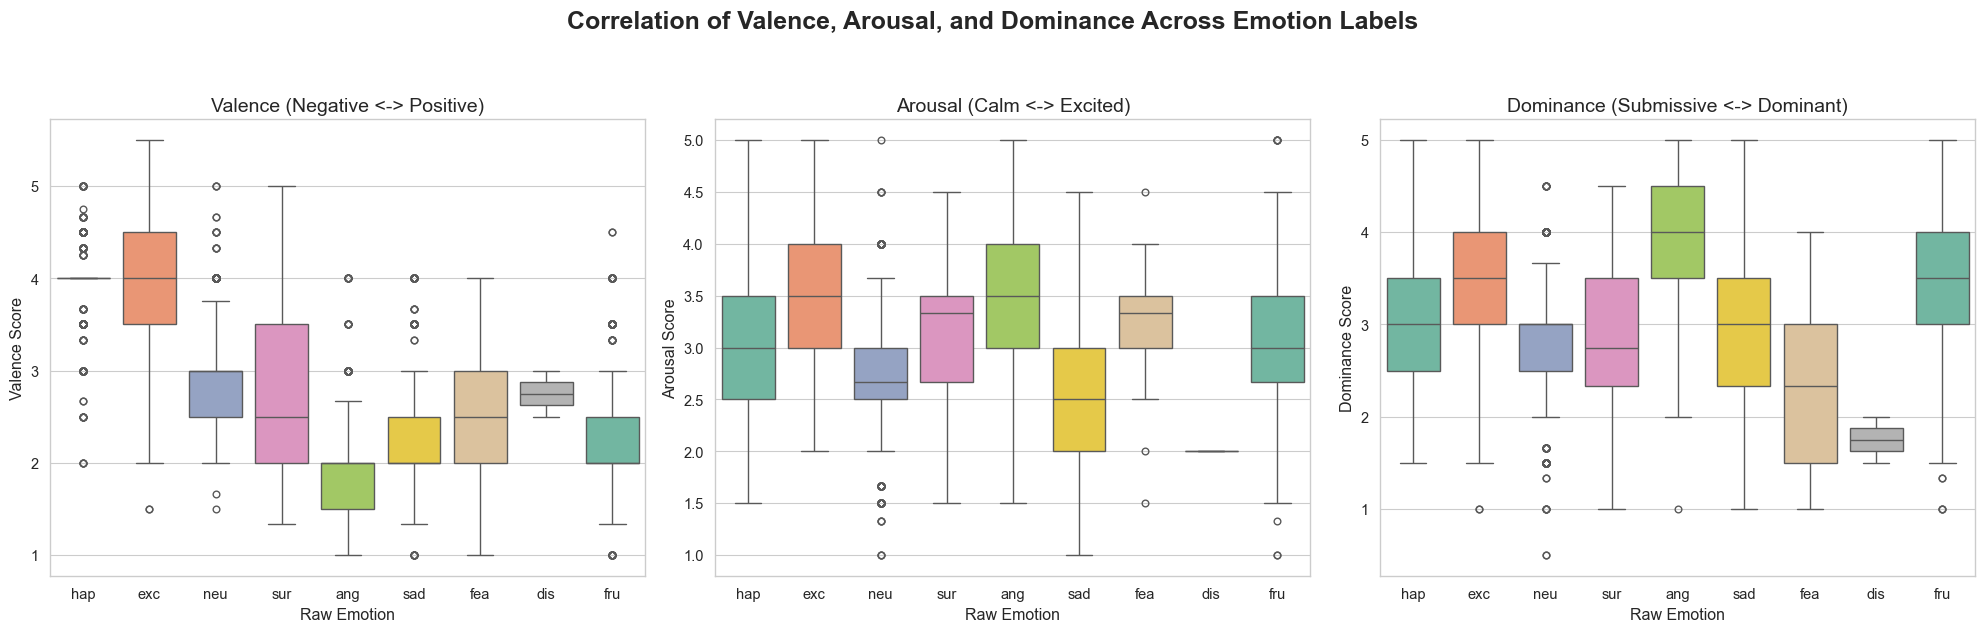

In [3]:
# =====================================================================
# STEP 1.4: V-A-D DISTRIBUTION BY EMOTION (BOXPLOTS)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out undefined labels ('xxx', 'oth') to ensure a cleaner visualization.
# Alternatively, retain the entire dataset by modifying this filter.
target_df = df[df['Stage1_Label'] != -1].copy() 

# Initialize the canvas layout with 3 horizontal subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
fig.suptitle('Correlation of Valence, Arousal, and Dominance Across Emotion Labels', fontsize=18, fontweight='bold', y=1.05)

# Define chronological sorting by Macro Sentiment for better readability (Positive -> Neutral -> Negative)
emotion_order = ['hap', 'exc', 'neu', 'sur', 'ang', 'sad', 'fea', 'dis', 'fru']
# Re-filter the order array to only include emotional classes actually present in the current dataframe
emotion_order = [e for e in emotion_order if e in target_df['Raw_Emotion'].unique()]

# 1. Valence Distribution Plot
sns.boxplot(ax=axes[0], x='Raw_Emotion', y='Valence', data=target_df, order=emotion_order, palette='Set2')
axes[0].set_title('Valence (Negative <-> Positive)', fontsize=14)
axes[0].set_xlabel('Raw Emotion')
axes[0].set_ylabel('Valence Score')

# 2. Arousal Distribution Plot
sns.boxplot(ax=axes[1], x='Raw_Emotion', y='Arousal', data=target_df, order=emotion_order, palette='Set2')
axes[1].set_title('Arousal (Calm <-> Excited)', fontsize=14)
axes[1].set_xlabel('Raw Emotion')
axes[1].set_ylabel('Arousal Score')

# 3. Dominance Distribution Plot
sns.boxplot(ax=axes[2], x='Raw_Emotion', y='Dominance', data=target_df, order=emotion_order, palette='Set2')
axes[2].set_title('Dominance (Submissive <-> Dominant)', fontsize=14)
axes[2].set_xlabel('Raw Emotion')
axes[2].set_ylabel('Dominance Score')

# Adjust layout automatically for tight distribution alignment
plt.tight_layout()
plt.show()

### Step 1.3: Biometric & Physical Statistics
**Description:** *Note: Requires 'Duration_sec', 'F0_Mean', and 'Speaker_Gender' columns.* Analyzes physical acoustic characteristics to understand biological variances, such as Fundamental Frequency (F0) distribution across genders and emotion classes.

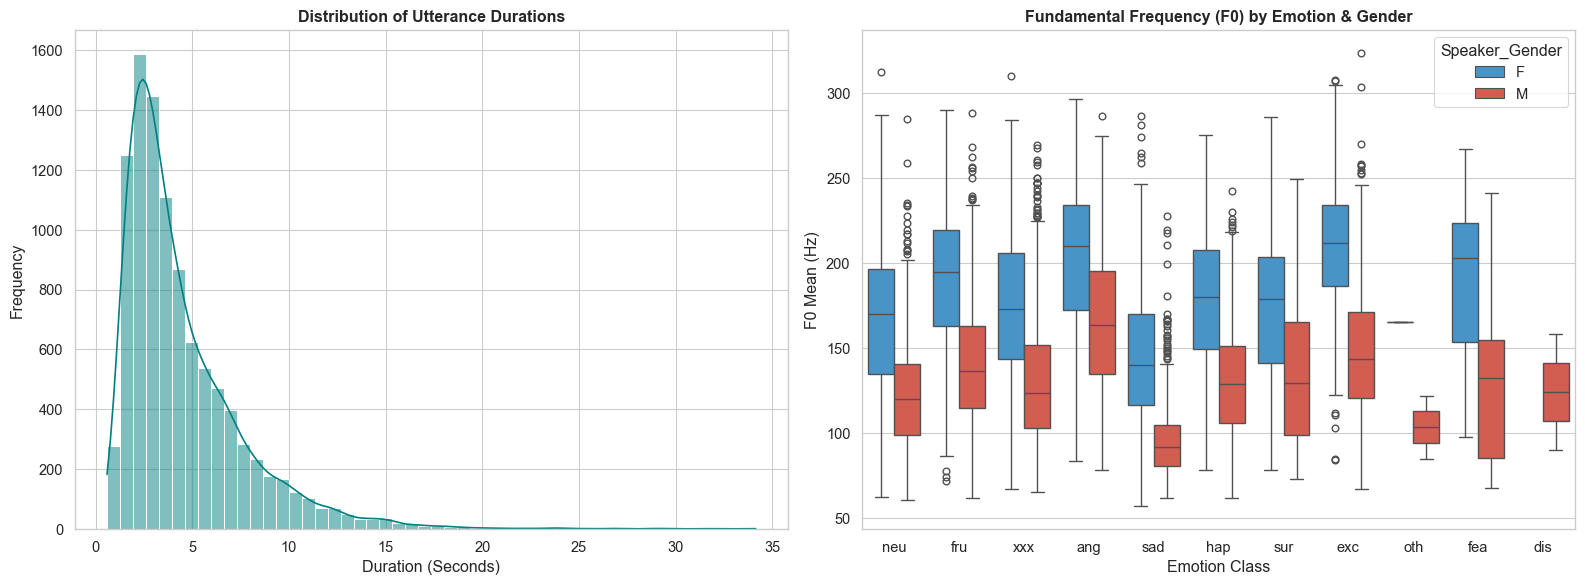

[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.


In [16]:
# =====================================================================
# BIOMETRIC DISTRIBUTIONS (TEMPLATE)
# =====================================================================


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Utterance Duration Distribution
sns.histplot(df['Duration_sec'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Utterance Durations', fontweight='bold')
axes[0].set_xlabel('Duration (Seconds)')
axes[0].set_ylabel('Frequency')

# 2. F0 (Pitch) Boxplot by Emotion and Gender
sns.boxplot(
    data=df, 
    x='Raw_Emotion', 
    y='F0_Mean', 
    hue='Speaker_Gender', 
    palette=['#3498db', '#e74c3c'], 
    ax=axes[1]
)
axes[1].set_title('Fundamental Frequency (F0) by Emotion & Gender', fontweight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('F0 Mean (Hz)')

plt.tight_layout()
plt.show()

print("[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.")

### Step 1.4: Conversational Dynamics (Markov Chain Heatmap)
**Description:** Calculates the state-transition probability matrix from utterance $t-1$ to utterance $t$ within the same dialogue. Retains unknown ('xxx') labels to preserve temporal sequence integrity. This maps the emotional inertia and transition patterns in natural conversations.

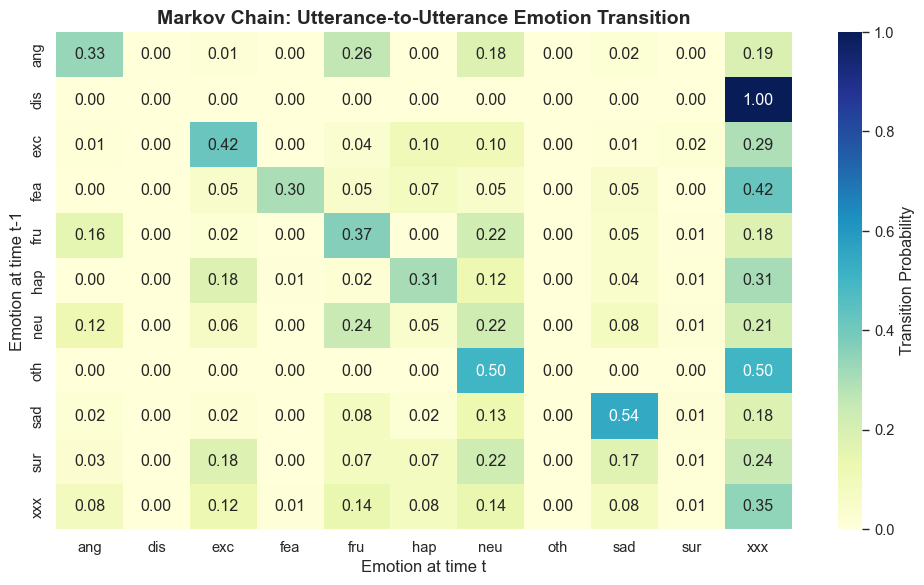

In [3]:
# =====================================================================
# MARKOV CHAIN: EMOTION TRANSITION MATRIX
# =====================================================================
# Create a new column representing the emotion of the NEXT utterance (t+1)
# Grouping by 'Dialog_ID' prevents transitions between separate dialogues.
df['Next_Emotion'] = df.groupby('Dialog_ID')['Raw_Emotion'].shift(-1)

# Drop the last utterances of each dialog (no 'next' state available)
transitions_df = df.dropna(subset=['Next_Emotion'])

# Calculate the cross-tabulation matrix (normalized by row to get probabilities)
transition_matrix = pd.crosstab(
    transitions_df['Raw_Emotion'], 
    transitions_df['Next_Emotion'], 
    normalize='index'
)

# Plotting the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    transition_matrix, 
    annot=True,          # Show probability numbers
    fmt=".2f",           # Format to 2 decimal places
    cmap="YlGnBu",       # Standard analytical color map
    cbar_kws={'label': 'Transition Probability'}
)

plt.title("Markov Chain: Utterance-to-Utterance Emotion Transition", fontsize=14, fontweight='bold')
plt.xlabel("Emotion at time t", fontsize=12)
plt.ylabel("Emotion at time t-1", fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation Focus: 
# High values along the diagonal indicate "Emotional Inertia" (remaining in the same state).